# Lecture 10 - Spring 2024

Data Science, Spring 2024

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import itertools
from mpl_toolkits.mplot3d import Axes3D

In [2]:
# Big font helper
def adjust_fontsize(size=None):
    SMALL_SIZE = 8
    MEDIUM_SIZE = 10
    BIGGER_SIZE = 12
    if size != None:
        SMALL_SIZE = MEDIUM_SIZE = BIGGER_SIZE = size

    plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
    plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
    plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
    plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
    plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
    plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
    plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

# 1st Task

We will first define some helper functions to calculate the regression line for us. Apply these helper funtions on house price dataset and compare with your previous model (you built using sklearn built-in funtions).

In [18]:
house = pd.read_csv("SLR_house_prices.csv")
house.isnull().sum()

area     20
price    28
dtype: int64

In [19]:
house['area']=house['area'].isnull().replace(house['area'].mean(),"")
house['price']=house['price'].isnull().replace(house['price'].mean(),"")

In [21]:
x=house[['area']]
y=house['price']

from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x,y)
model.coef_,model.intercept_

(array([-0.02857143]), 0.028571428571428574)

In [50]:
def standard_units(x):
    return (x-np.mean(x))/(np.std(x))

def correlation(x, y):
    z=standard_units(x)*standard_units(y)
    z=z.sum()/len(z)
    return z
def slope(x, y):
    z = (correlation(x, y)*(np.std(y))/np.std(x))
    return z
def intercept(x, y):
    z = np.mean(y) - (slope(x,y) * np.mean(x))
    return z

def fit_least_squares(x,y):
    theta_1 = slope(x,y)
    theta_0 = intercept(x,y)
    return theta_0,theta_1

def predict(x,theta_1,theta_0):
    return x*theta_1+theta_0



In [23]:
'''
The slope tells you the tilt or steepness of the line.
The intercept tells you where the line crosses the y-axis.

'''
print()

In [37]:
#Helper Function
# define standard unit function
def standard_units(x):
    return (x-np.mean(x))/(np.std(x))

# define correlation function
def correlation(x, y):
    z=standard_units(x)*standard_units(y)
    z=z.sum()/len(z)
    return z

# define slope function
def slope(x, y):
    z = (correlation(x, y)*(np.std(y))/np.std(x))
    return z

# define intercept function
def intercept(x, y):
    z = np.mean(y) - (slope(x,y) * np.mean(x))
    return z

# define fit_least_squares function
def fit_least_squares(x,y):
    theta_1 = slope(x,y)
    theta_0 = np.mean(y) - (np.mean(x)*theta_1)
    return theta_0,theta_1

# define predict function
def predict(x,theta_1,theta_0):
    return x*theta_1+theta_0

# define mse function
def compute_mse(y, yhat):
    z=(1/len(y)*(y-yhat)**2)
    return z

# 2nd Task
Let's look at four different datasets. Without visualizing the data, let's try fitting the simple linear regression model to these four datasets!

In [26]:
# Load in four different datasets: I, II, III, IV
x = [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5]
y1 = [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68]
y2 = [9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74]
y3 = [7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73]
x4 = [8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8]
y4 = [6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89]

# create dataframes

# apply SLR model on these four Datasets

In [39]:
#pd.DataFrame({"X":x,"Y":y1})

In [51]:
standard_units(x)

correlation(x, y1)
slope(x, y1)
intercept(x, y1)
print(f"Dataset1: theta_0: {fit_least_squares(x,y1)[0]}, theta_1: {fit_least_squares(x,y1)[1]}")

intercept(x, y2)
print(f"Dataset1: theta_0: {fit_least_squares(x,y1)[0]}, theta_1: {fit_least_squares(x,y1)[1]}")

intercept(x, y3)
print(f"Dataset1: theta_0: {fit_least_squares(x,y1)[0]}, theta_1: {fit_least_squares(x,y1)[1]}")

intercept(x, y4)
print(f"Dataset1: theta_0: {fit_least_squares(x,y1)[0]}, theta_1: {fit_least_squares(x,y1)[1]}")

Dataset1: theta_0: 3.000090909090911, theta_1: 0.500090909090909
Dataset1: theta_0: 3.000090909090911, theta_1: 0.500090909090909
Dataset1: theta_0: 3.000090909090911, theta_1: 0.500090909090909
Dataset1: theta_0: 3.000090909090911, theta_1: 0.500090909090909


In [ ]:
# print values of both parameters (slope, intercept) for all these Datasets

Dataset I: theta_0: 3.00, theta_1: 0.50
Dataset II: theta_0: 3.00, theta_1: 0.50
Dataset III: theta_0: 3.00, theta_1: 0.50
Dataset IV: theta_0: 3.00, theta_1: 0.50


Looks like all four datasets have exactly the same fit.

In fact, all four of them have the same $\bar x$, $\bar y$, $\sigma_x$, $\sigma_y$, correlation $r$, and RMSE! If we only look at these statistics, we will probably be inclined to say that these datasets are similar.

In [49]:
for dataset in ['I', 'II', 'III', 'IV']:
    print(f">>> Dataset {dataset}:")
    ans = anscombe[dataset]
    fig = least_squares_evaluation(ans['x'], ans['y'], visualize = NO_VIZ)
    print()
    print()

>>> Dataset I:


NameError: name 'anscombe' is not defined

In [ ]:
for dataset in ['I', 'II', 'III', 'IV']:
    print(f">>> Dataset {dataset}:")
    ans = anscombe[dataset]
    fig = least_squares_evaluation(ans['x'], ans['y'], visualize = NO_VIZ)
    print()
    print()

>>> Dataset I:
x_mean : 9.00, y_mean : 7.50
x_stdev: 3.16, y_stdev: 1.94
r = Correlation(x, y): 0.816
	heta_0: 3.00, 	heta_1: 0.50
RMSE: 1.119


>>> Dataset II:
x_mean : 9.00, y_mean : 7.50
x_stdev: 3.16, y_stdev: 1.94
r = Correlation(x, y): 0.816
	heta_0: 3.00, 	heta_1: 0.50
RMSE: 1.119


>>> Dataset III:
x_mean : 9.00, y_mean : 7.50
x_stdev: 3.16, y_stdev: 1.94
r = Correlation(x, y): 0.816
	heta_0: 3.00, 	heta_1: 0.50
RMSE: 1.118


>>> Dataset IV:
x_mean : 9.00, y_mean : 7.50
x_stdev: 3.16, y_stdev: 1.94
r = Correlation(x, y): 0.817
	heta_0: 3.00, 	heta_1: 0.50
RMSE: 1.118




However, it is only when we visualize the datasets that we realize only one of these four sets of data makes sense to model using SLR.

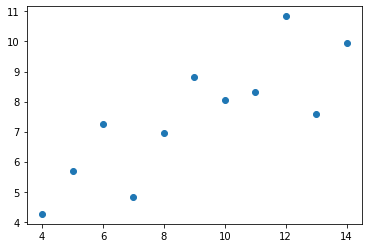

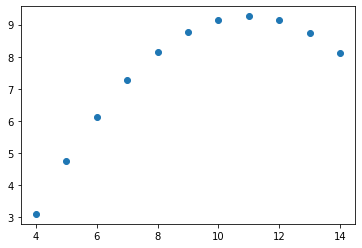

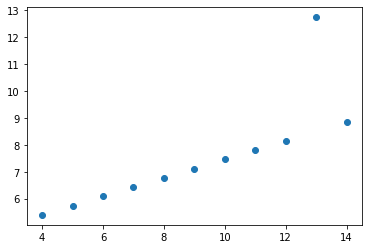

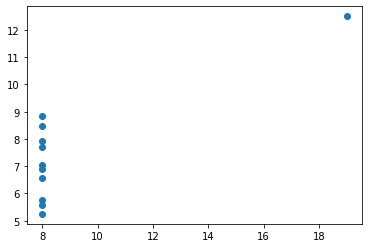

In [48]:
plt.scatter(x,y1)
plt.show()
plt.scatter(x,y2)
plt.show()
plt.scatter(x,y3)
plt.show()
plt.scatter(x4,y4)

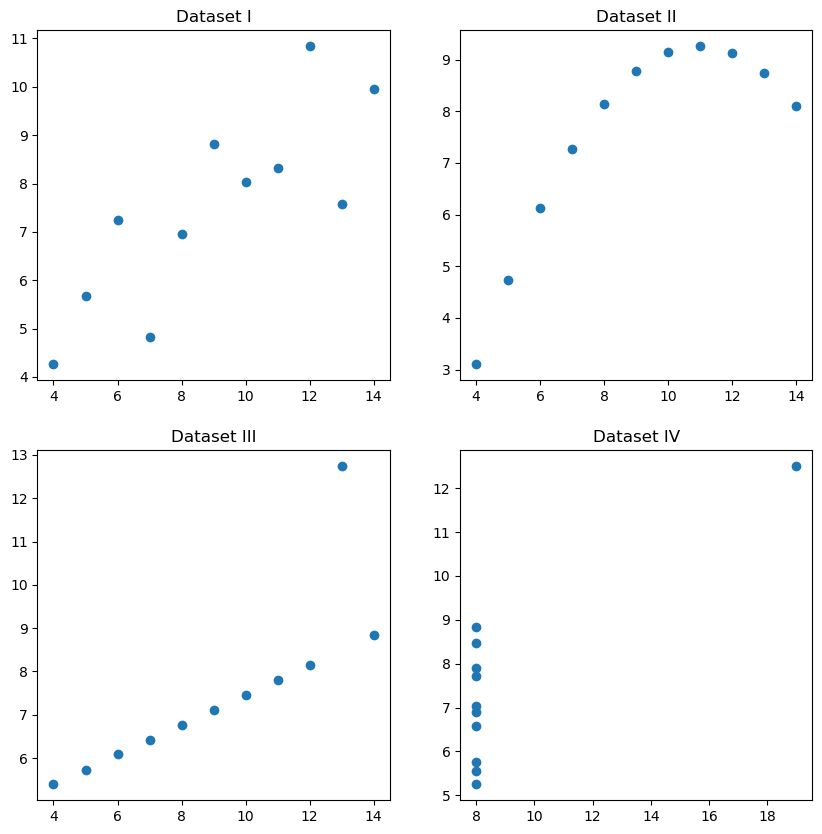

In [ ]:
# visualize all four datasets

Checking the residuals will also shed light on the differences among these four datasets.

If you remember from Data 8, "the residual plot of a good regression shows no pattern".

>>> Dataset I:
x_mean : 9.00, y_mean : 7.50
x_stdev: 3.16, y_stdev: 1.94
r = Correlation(x, y): 0.816
	heta_0: 3.00, 	heta_1: 0.50
RMSE: 1.119


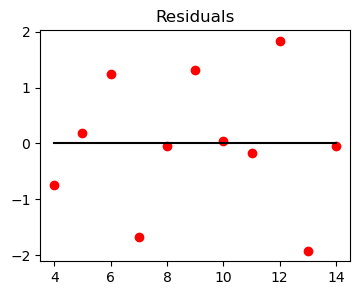



>>> Dataset II:
x_mean : 9.00, y_mean : 7.50
x_stdev: 3.16, y_stdev: 1.94
r = Correlation(x, y): 0.816
	heta_0: 3.00, 	heta_1: 0.50
RMSE: 1.119


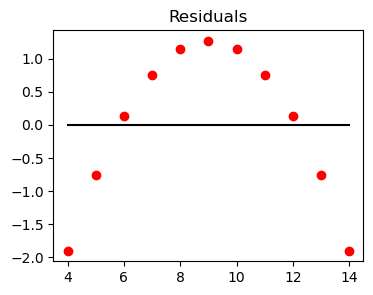



>>> Dataset III:
x_mean : 9.00, y_mean : 7.50
x_stdev: 3.16, y_stdev: 1.94
r = Correlation(x, y): 0.816
	heta_0: 3.00, 	heta_1: 0.50
RMSE: 1.118


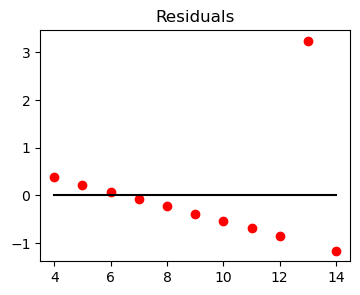



>>> Dataset IV:
x_mean : 9.00, y_mean : 7.50
x_stdev: 3.16, y_stdev: 1.94
r = Correlation(x, y): 0.817
	heta_0: 3.00, 	heta_1: 0.50
RMSE: 1.118


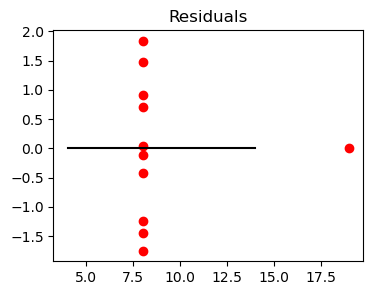

In [ ]:
# plot residual with respect to x for all four Datasets

The takeaway here is that you should always visualize your datasets before fitting any models to it!